In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pylab import rcParams
from pathlib import Path

Directory for images/graphs

In [18]:
Path("figures").mkdir(parents=True, exist_ok=True)

#Default figure size in the "figure" directory
rcParams['figure.figsize'] = (4, 4)

#Telling pandas how to display floats
pd.options.display.float_format = "{:,.2f}".format

Load the cleaned data

In [19]:
path = "data/wti_cleaned.csv"
data = pd.read_csv(path, parse_dates=["date"])
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10513 entries, 0 to 10512
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    10513 non-null  datetime64[ns]
 1   price   10513 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 164.4 KB


,date,price
0,1986-01-02,25.56
1,1986-01-03,26.00
2,1986-01-06,26.53
3,1986-01-07,25.85
4,1986-01-08,25.87


In [20]:
data.columns

Index(['date', 'price'], dtype='object')

Processing

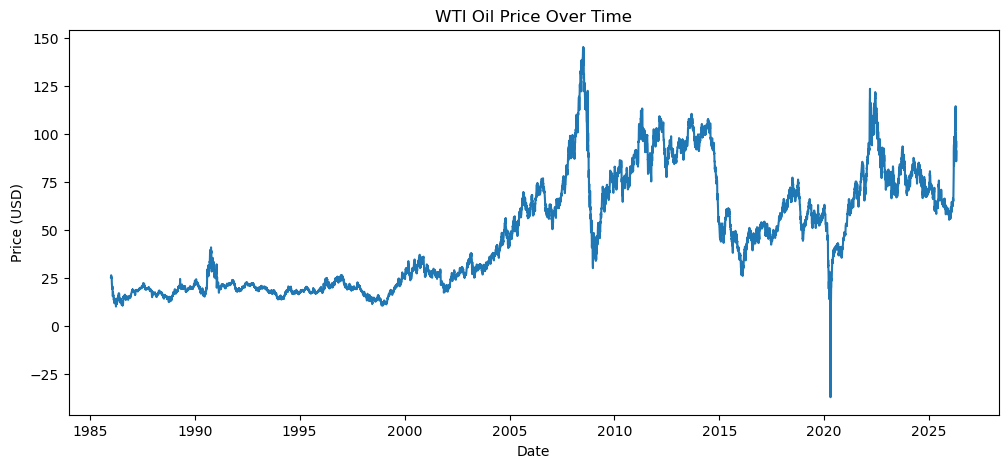

In [21]:
plt.figure(figsize=(12,5))
plt.plot(data["date"], data["price"])
plt.title("WTI Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

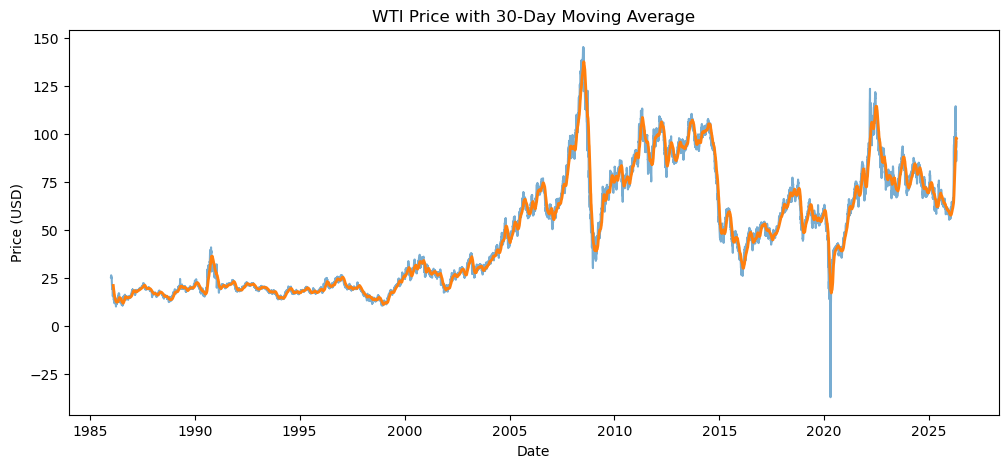

In [23]:
data["MA30"] = data["price"].rolling(30).mean()
plt.figure(figsize=(12,5))
plt.plot(data["date"], data["price"], alpha=0.6)
plt.plot(data["date"], data["MA30"], linewidth=2)
plt.title("WTI Price with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.savefig("figures/wti_moving_average.png")
plt.show()

In [24]:
#Only the first 29 values in our new column should be NaN. The right data is being loaded and processed.
data["MA30"].isna().sum()

np.int64(29)

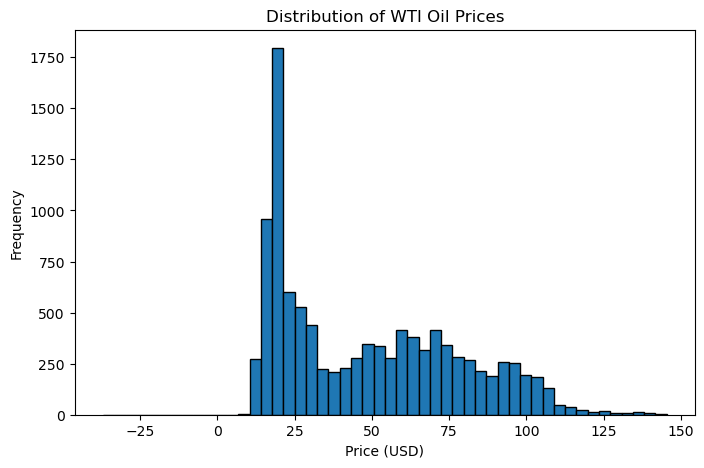

In [25]:
plt.figure(figsize=(8,5))
plt.hist(data['price'], bins=50, edgecolor="black")
plt.title("Distribution of WTI Oil Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.savefig("figures/wti_price_distribution.png")
plt.show()

It is also very valuable to see the daily change in oil prices and graph said values

In [30]:
data["returns"] = data["price"].pct_change()


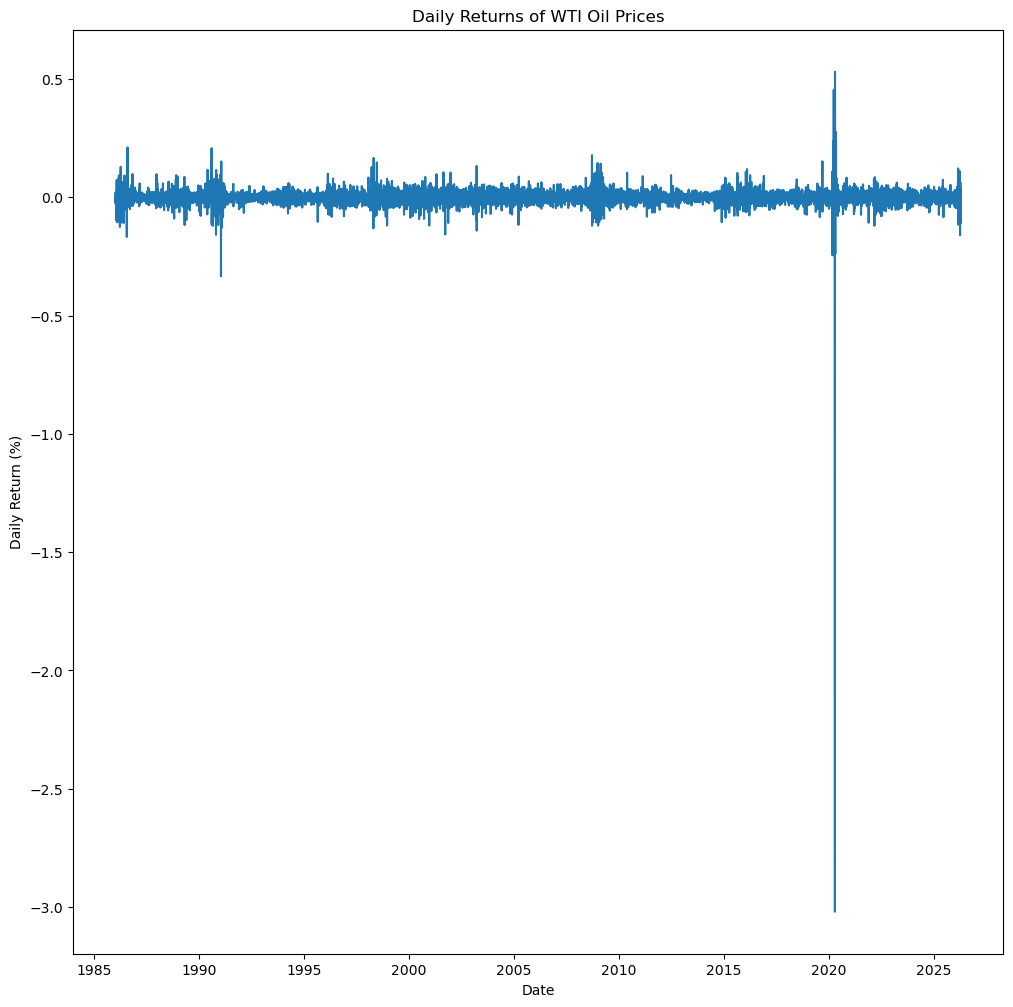

In [33]:
plt.figure(figsize=(12,12
                   ))
plt.plot(data["date"], data["returns"])

plt.title("Daily Returns of WTI Oil Prices")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.savefig("figures/wti_daily_returns.png")
plt.show()


Yearly average

In [39]:
data["year"] = data["date"].dt.year
yearly_avg = data.groupby("year")["price"].mean()


yearly_avg.head()

year
1986   15.05
1987   19.18
1988   15.97
1989   19.63
1990   24.47
Name: price, dtype: float64

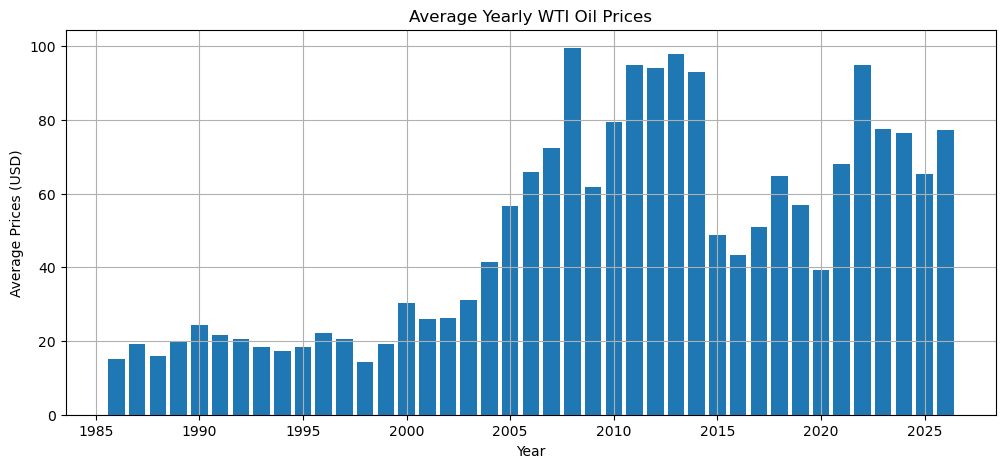

In [46]:
plt.figure(figsize=(12, 5))
plt.bar(yearly_avg.index, yearly_avg.values)

plt.title("Average Yearly WTI Oil Prices")
plt.xlabel("Year")
plt.ylabel("Average Prices (USD)")
plt.grid(True)
plt.savefig("figures/yearly_wti_avg.png")
plt.show()

Now 